# Planar Data Classification with One Hidden Layer

In this notebook, we will build a neural network with a single hidden layer to perform binary classification on a planar dataset.

In [1]:
# Package imports
import numpy as np
import matplotlib.pyplot as plt
from planar_utils import plot_decision_boundary, sigmoid, load_planar_dataset, load_extra_datasets

%matplotlib inline
np.random.seed(1)

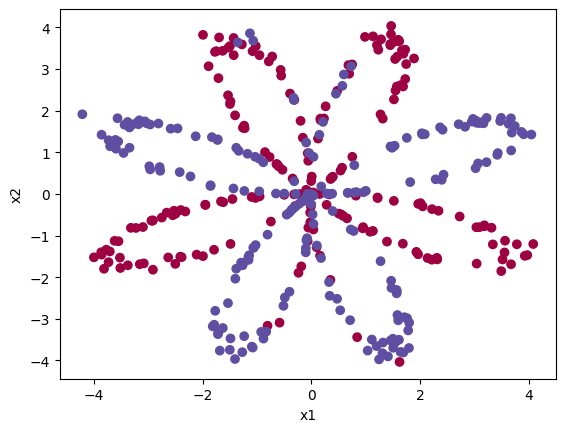

The shape of X is: (2, 400)
The shape of Y is: (1, 400)
I have m = 400 training examples!


In [2]:
# Load and visualize the data:
X, Y = load_planar_dataset()

plt.scatter(X[0, :], X[1, :], c=Y.ravel(), cmap=plt.cm.Spectral)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# Dimensions of the dataset
shape_X = X.shape
shape_Y = Y.shape
m = X.shape[1]  # training set size

print('The shape of X is:', shape_X)
print('The shape of Y is:', shape_Y)
print('I have m =', m, 'training examples!')

In [3]:
def layer_sizes(X, Y):
    """
    Arguments:
    X -- input dataset of shape (input size, number of examples)
    Y -- labels of shape (output size, number of examples)
    
    Returns:
    n_x -- the size of the input layer
    n_h -- the size of the hidden layer
    n_y -- the size of the output layer
    """
    n_x = X.shape[0]  # size of input layer
    n_h = 4  # size of hidden layer
    n_y = Y.shape[0]  # size of output layer
    
    return (n_x, n_h, n_y)

In [4]:
def initialize_parameters(n_x, n_h, n_y):
    """
    Initialize the neural network parameters.
    
    Returns:
    parameters -- python dictionary containing parameters:
                    W1 -- weight matrix of shape (n_h, n_x)
                    b1 -- bias vector of shape (n_h, 1)
                    W2 -- weight matrix of shape (n_y, n_h)
                    b2 -- bias vector of shape (n_y, 1)
    """
    
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    
    parameters = {"W1": W1,
                 "b1": b1,
                 "W2": W2,
                 "b2": b2}
    
    return parameters

In [5]:
def forward_propagation(X, parameters):
    """
    Implement forward propagation.
    
    Arguments:
    X -- input data of size (n_x, m)
    parameters -- python dictionary containing parameters
    
    Returns:
    A2 -- The sigmoid output of the second activation
    cache -- dictionary containing "Z1", "A1", "Z2" and "A2"
    """
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)
    
    cache = {"Z1": Z1,
            "A1": A1,
            "Z2": Z2,
            "A2": A2}
    
    return A2, cache

In [6]:
def compute_cost(A2, Y):
    """
    Compute the cross-entropy cost.
    
    Arguments:
    A2 -- The sigmoid output of the second activation, shape (1, number of examples)
    Y -- "true" labels vector of shape (1, number of examples)
    
    Returns:
    cost -- cross-entropy cost
    """
    m = Y.shape[1]
    
    logprobs = np.multiply(np.log(A2), Y) + np.multiply(np.log(1 - A2), 1 - Y)
    cost = -np.sum(logprobs) / m
    
    return float(np.squeeze(cost))

In [ ]:
def backward_propagation(parameters, cache, X, Y):
    """
    Implement backward propagation.
    
    Arguments:
    parameters -- python dictionary containing parameters 
    cache -- dictionary containing "Z1", "A1", "Z2" and "A2"
    X -- input data of shape (2, number of examples)
    Y -- "true" labels vector of shape (1, number of examples)
    
    Returns:
    grads -- python dictionary containing gradients with respect to different parameters
    """
    m = X.shape[1]
    
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    A1 = cache["A1"]
    A2 = cache["A2"]
    
    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = np.multiply(np.dot(W2.T, dZ2), 1 - np.power(A1, 2))
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    
    grads = {"dW1": dW1,
            "db1": db1,
            "dW2": dW2,
            "db2": db2}
    
    return grads

In [ ]:
def update_parameters(parameters, grads, learning_rate=1.2):
    """
    Update parameters using gradient descent.
    
    Arguments:
    parameters -- python dictionary containing parameters
    grads -- python dictionary containing gradients
    
    Returns:
    parameters -- python dictionary containing updated parameters
    """
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    dW1 = grads["dW1"]
    db1 = grads["db1"]
    dW2 = grads["dW2"]
    db2 = grads["db2"]
    
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    
    parameters = {"W1": W1,
                 "b1": b1,
                 "W2": W2,
                 "b2": b2}
    
    return parameters

In [ ]:
def nn_model(X, Y, n_h, num_iterations=10000, print_cost=False):
    """
    Arguments:
    X -- dataset of shape (2, number of examples)
    Y -- labels of shape (1, number of examples)
    n_h -- size of the hidden layer
    num_iterations -- Number of iterations in gradient descent loop
    print_cost -- if True, print the cost every 1000 iterations
    
    Returns:
    parameters -- parameters learnt by the model
    """
    
    np.random.seed(3)
    n_x = layer_sizes(X, Y)[0]
    n_y = layer_sizes(X, Y)[2]
    
    parameters = initialize_parameters(n_x, n_h, n_y)
    
    for i in range(num_iterations):
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads)
        
        if print_cost and i % 1000 == 0:
            print("Cost after iteration %i: %f" % (i, cost))
    
    return parameters

In [ ]:
def predict(parameters, X):
    """
    Using the learned parameters, predicts a class for each example in X
    
    Arguments:
    parameters -- python dictionary containing parameters 
    X -- input data of size (n_x, m)
    
    Returns:
    predictions -- vector of predictions of our model
    """
    
    A2, cache = forward_propagation(X, parameters)
    predictions = np.round(A2)
    
    return predictions

In [ ]:
# Build a model with a 4-unit hidden layer
parameters = nn_model(X, Y, n_h=4, num_iterations=10000, print_cost=True)

# Plot the decision boundary
plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
plt.title("Decision Boundary for hidden layer size " + str(4))

# Print accuracy
predictions = predict(parameters, X)
print('Accuracy: %d' % float((np.dot(Y, predictions.T) + np.dot(1-Y, 1-predictions.T)) / float(Y.size) * 100) + '%')